<a href="https://colab.research.google.com/github/GeorgeT27/Generative-model-DYI/blob/main/Copy_of_Conditional_Flow_Matching_Morpho_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Compose, Normalize
from torch.utils.data import DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import StepLR
import torch.distributions as distributions
from tqdm import tqdm
import pandas as pd
from copy import deepcopy
import os
import sys
sys.path.append('/workspace/Generative-model-DYI/Morpho-MNIST/')
from morphomnist import io

In [6]:
class RectifiedFlow:
  def euler(self,x_t,v,dt):
    x_t=x_t+v*dt
    return x_t
  def create_flow(self,x_1,t):
    x_0=torch.randn_like(x_1)
    t=t[:,None,None,None]
    x_t=t*x_1+(1-t)*x_0
    return x_t,x_0
  def mse_loss(self,x_1,x_0,v):
    loss=F.mse_loss(x_1-x_0,v)
    return loss

In [ ]:
# Replace your existing FiLM model with this improved deep version

class ImprovedFiLMLayer(nn.Module):
    """Better FiLM layer with proper initialization and optional bypass"""
    def __init__(self, num_features, condition_dim, use_film=True):
        super().__init__()
        self.use_film = use_film
        
        if use_film:
            self.scale_transform = nn.Linear(condition_dim, num_features)
            self.shift_transform = nn.Linear(condition_dim, num_features)
            
            # Better initialization - start closer to identity
            nn.init.zeros_(self.scale_transform.weight)
            nn.init.zeros_(self.scale_transform.bias)
            nn.init.zeros_(self.shift_transform.weight)
            nn.init.zeros_(self.shift_transform.bias)
    
    def forward(self, x, condition):
        if not self.use_film or condition is None:
            return x
            
        scale = self.scale_transform(condition).unsqueeze(-1).unsqueeze(-1)
        shift = self.shift_transform(condition).unsqueeze(-1).unsqueeze(-1)
        
        # Apply FiLM: x * (1 + scale) + shift (more stable than x * scale + shift)
        return x * (1 + scale) + shift

class DeepResBlockFiLM(nn.Module):
    """Deep residual block with FiLM conditioning"""
    
    def __init__(self, in_channels, out_channels, condition_dim, use_film=True, dropout=0.1):
        super().__init__()
        
        # First conv path
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(8, out_channels), out_channels)
        self.film1 = ImprovedFiLMLayer(out_channels, condition_dim, use_film)
        
        # Second conv path
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(min(8, out_channels), out_channels)
        self.film2 = ImprovedFiLMLayer(out_channels, condition_dim, use_film)
        
        # Dropout for regularization
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        
        # Shortcut connection
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        
        self.act = nn.SiLU()  # Better activation than ReLU
    
    def forward(self, x, condition=None):
        residual = self.shortcut(x)
        
        # First conv block
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.film1(h, condition)
        h = self.act(h)
        h = self.dropout(h)
        
        # Second conv block
        h = self.conv2(h)
        h = self.norm2(h)
        h = self.film2(h, condition)
        
        # Residual connection
        return self.act(h + residual)

class AttentionBlock(nn.Module):
    """Self-attention block for better feature processing"""
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.norm = nn.GroupNorm(min(8, channels), channels)
        self.q = nn.Conv2d(channels, channels, 1)
        self.k = nn.Conv2d(channels, channels, 1)
        self.v = nn.Conv2d(channels, channels, 1)
        self.proj_out = nn.Conv2d(channels, channels, 1)
        
    def forward(self, x):
        h_ = self.norm(x)
        q = self.q(h_)
        k = self.k(h_)
        v = self.v(h_)
        
        # Compute attention
        b, c, h, w = q.shape
        q = q.reshape(b, c, h * w).transpose(1, 2)
        k = k.reshape(b, c, h * w)
        v = v.reshape(b, c, h * w).transpose(1, 2)
        
        attn = torch.bmm(q, k) * (c ** -0.5)
        attn = F.softmax(attn, dim=-1)
        
        h_ = torch.bmm(attn, v).transpose(1, 2).reshape(b, c, h, w)
        h_ = self.proj_out(h_)
        
        return x + h_

class DeepMiniUnetFiLM(nn.Module):
    """Deep U-Net with FiLM conditioning - much better capacity"""
    
    def __init__(self, base_channels=64, condition_dim=128, use_morphometrics=False, 
                 num_res_blocks=2, use_attention=True, dropout=0.1):
        super().__init__()
        
        self.condition_dim = condition_dim
        self.base_channels = base_channels
        self.use_morphometrics = use_morphometrics
        self.use_attention = use_attention
        
        # Time embedding (much better)
        self.time_embed = nn.Sequential(
            nn.Linear(base_channels, condition_dim),
            nn.SiLU(),
            nn.Linear(condition_dim, condition_dim),
        )
        
        # Label embedding
        self.label_embed = nn.Embedding(11, condition_dim)  # 0-9 + unconditional
        
        # Morphometric embedding (only if needed)
        if use_morphometrics:
            self.morpho_net = nn.Sequential(
                nn.Linear(3, condition_dim // 2),  # area, thickness, length
                nn.SiLU(),
                nn.Linear(condition_dim // 2, condition_dim),
                nn.SiLU(),
                nn.Linear(condition_dim, condition_dim)
            )
        
        # Input layer
        self.conv_in = nn.Conv2d(1, base_channels, 3, padding=1)
        
        # Encoder (4 levels for much more depth)
        self.down_blocks = nn.ModuleList()
        self.down_pools = nn.ModuleList()
        
        channels = [base_channels, base_channels*2, base_channels*4, base_channels*8, base_channels*8]
        
        for i in range(4):
            blocks = nn.ModuleList()
            for j in range(num_res_blocks):
                in_ch = channels[i] if j == 0 else channels[i+1]
                blocks.append(DeepResBlockFiLM(in_ch, channels[i+1], condition_dim, True, dropout))
            
            # Add attention at middle resolutions
            if use_attention and i in [1, 2]:
                blocks.append(AttentionBlock(channels[i+1]))
                
            self.down_blocks.append(blocks)
            
            if i < 3:  # No pooling after last block
                self.down_pools.append(nn.Conv2d(channels[i+1], channels[i+1], 3, stride=2, padding=1))
        
        # Middle blocks with attention
        self.middle_blocks = nn.ModuleList([
            DeepResBlockFiLM(channels[-1], channels[-1], condition_dim, True, dropout),
            AttentionBlock(channels[-1]) if use_attention else nn.Identity(),
            DeepResBlockFiLM(channels[-1], channels[-1], condition_dim, True, dropout),
        ])
        
        # Decoder
        self.up_blocks = nn.ModuleList()
        self.up_samples = nn.ModuleList()
        
        for i in range(3, -1, -1):
            # Upsample first
            if i < 3:
                self.up_samples.append(nn.ConvTranspose2d(channels[i+2], channels[i+1], 4, stride=2, padding=1))
            
            blocks = nn.ModuleList()
            for j in range(num_res_blocks):
                in_ch = channels[i+2] + channels[i+1] if j == 0 and i < 3 else channels[i+1]
                in_ch = channels[i+1] if j == 0 and i == 3 else in_ch
                blocks.append(DeepResBlockFiLM(in_ch, channels[i+1], condition_dim, True, dropout))
            
            # Add attention at middle resolutions
            if use_attention and i in [1, 2]:
                blocks.append(AttentionBlock(channels[i+1]))
                
            self.up_blocks.append(blocks)
        
        # Output layer
        self.norm_out = nn.GroupNorm(min(8, base_channels), base_channels)
        self.conv_out = nn.Conv2d(base_channels, 1, 3, padding=1)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    
    def get_time_embedding(self, t):
        """Sinusoidal time embedding"""
        half_dim = self.base_channels // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return self.time_embed(emb)
    
    def forward(self, x, t, y=None, morpho=None):
        # Build conditioning vector
        condition = self.get_time_embedding(t)
        
        # Add label conditioning
        if y is not None:
            y_mapped = torch.where(y == -1, torch.tensor(10, device=y.device), y)
            label_emb = self.label_embed(y_mapped)
            condition = condition + label_emb
        
        # Add morphometric conditioning (only if enabled and provided)
        if morpho is not None and self.use_morphometrics:
            # Normalize morphometrics
            area_norm = (morpho['area'] - 112.79) / 84.32
            thickness_norm = (morpho['thickness'] - 3.13) / 1.98
            length_norm = (morpho['length'] - 37.38) / 10.47
            
            morpho_vec = torch.stack([
                torch.clamp(area_norm, -3, 3),
                torch.clamp(thickness_norm, -3, 3),
                torch.clamp(length_norm, -3, 3)
            ], dim=-1)
            
            morpho_emb = self.morpho_net(morpho_vec)
            condition = condition + morpho_emb
        
        # Input
        h = self.conv_in(x)
        
        # Encoder with skip connections
        skip_connections = []
        
        for i, (blocks, pool) in enumerate(zip(self.down_blocks, self.down_pools + [None])):
            for block in blocks:
                if isinstance(block, AttentionBlock):
                    h = block(h)
                else:
                    h = block(h, condition)
            
            skip_connections.append(h)
            
            if pool is not None:
                h = pool(h)
        
        # Middle
        for block in self.middle_blocks:
            if isinstance(block, AttentionBlock):
                h = block(h)
            elif hasattr(block, 'forward'):
                h = block(h, condition)
        
        # Decoder
        for i, (blocks, upsample) in enumerate(zip(self.up_blocks, [None] + list(self.up_samples))):
            if upsample is not None:
                h = upsample(h)
                # Concatenate skip connection
                skip = skip_connections[-(i+1)]
                h = torch.cat([h, skip], dim=1)
            
            for block in blocks:
                if isinstance(block, AttentionBlock):
                    h = block(h)
                else:
                    h = block(h, condition)
        
        # Output
        h = self.norm_out(h)
        h = F.silu(h)
        return self.conv_out(h)

# Also create a non-FiLM version for comparison
class DeepMiniUnetStandard(DeepMiniUnetFiLM):
    """Same architecture but without FiLM for comparison"""
    
    def __init__(self, base_channels=64, condition_dim=128, use_morphometrics=False,
                 num_res_blocks=2, use_attention=True, dropout=0.1):
        
        # Initialize with FiLM disabled
        super().__init__(base_channels, condition_dim, use_morphometrics, 
                        num_res_blocks, use_attention, dropout)
        
        # Replace all FiLM blocks with standard ones
        self._disable_film()
    
    def _disable_film(self):
        """Replace FiLM layers with standard additive conditioning"""
        def replace_film_in_module(module):
            for name, child in module.named_children():
                if isinstance(child, DeepResBlockFiLM):
                    # Replace FiLM layers with identity
                    child.film1.use_film = False
                    child.film2.use_film = False
                else:
                    replace_film_in_module(child)
        
        replace_film_in_module(self)

In [8]:
class EMA(nn.Module):
    def __init__(self, model, decay=0.9999, device=None):
        super(EMA, self).__init__()
        # make a copy of the model for accumulating moving average of weights
        self.module = deepcopy(model)
        self.module.eval()
        self.decay = decay
        self.device = device  # perform EMA on different device from model if set
        if self.device is not None:
            self.module.to(device=self.device)

    def _update(self, model, update_fn):
        with torch.no_grad():
            for ema_v, model_v in zip(self.module.state_dict().values(),
                                      model.state_dict().values()):
                if self.device is not None:
                    model_v = model_v.to(device=self.device)
                ema_v.copy_(update_fn(ema_v, model_v))

    def update(self, model):
        self._update(
            model,
            update_fn=lambda e, m: self.decay * e + (1.0 - self.decay) * m
        )

    def set(self, model):
        self._update(
            model,
            update_fn=lambda e, m: m
        )

In [9]:
# Improved training configuration
epochs= 100  # More epochs
batch_size= 128  # Larger batch size for more stable gradients
lr= 5e-4  # Slightly higher learning rate initially
weight_decay= 1e-4  # Less regularization
ema_decay= 0.9999
grad_clip= 1.0
lr_schedule= True
step_size= 40  # Reduce LR later
gamma= 0.5 # More gradual LR reduction
lr_adjust_epoch= 25 # 学习率调整的epoch，降为原有的10%
batch_print_interval= 100 # 打印间隔，以batch为单位
device= 'cuda' # cuda、cpu、mps(only macbook)
checkpoint_save_interval= 10 # 模型保存间隔，以epoch为单位

## Download Morpho-MNIST Dataset

Morpho-MNIST provides several dataset variants:

- **plain**: Plain digits only (16 MB)
- **global**: Plain + thinning + thickening (15 MB)  
- **local**: Plain + swelling + fractures (16 MB)
- **thin**: Thinning only (13 MB)
- **thic**: Thickening only (16 MB)
- **swel**: Swelling only (17 MB)
- **frac**: Fractures only (16 MB)

### Manual Download Required:
1. Go to: https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL
2. Download one of the datasets (e.g., "global" for diverse perturbations)
3. Extract to: `/Users/tqa946816/Generative-model-DYI/data/morpho-mnist/`

### Dataset Structure:
Each dataset contains:
- `[train|t10k]-images-idx3-ubyte.gz`: Images
- `[train|t10k]-labels-idx1-ubyte.gz`: Digit labels (0-9)
- `[train|t10k]-morpho.csv`: Morphometrics (area, length, thickness, slant, width, height)
- `[train|t10k]-pert-idx1-ubyte.gz`: Perturbation labels (0: plain, 1: thinned, 2: thickened, 3: swollen, 4: fractured)

In [10]:
class MorphoMNISTDataset(torch.utils.data.Dataset):
    """Custom dataset class for Morpho-MNIST data"""

    def __init__(self, root, train=True, download=False, transform=None,
                 load_morphometrics=False, load_perturbations=False):
        self.root = root
        self.train = train
        self.transform = transform
        self.load_morphometrics = load_morphometrics
        self.load_perturbations = load_perturbations

        # Create morpho-mnist directory
        self.morpho_dir = os.path.join(root, 'Morpho_MNIST/global')
        if not os.path.exists(self.morpho_dir):
            os.makedirs(self.morpho_dir)

        if download:
            self.download_data()

        # Load data
        self.data, self.targets, self.morphometrics, self.perturbations = self._load_data()

    def download_data(self):
        """Download Morpho-MNIST data if not exists"""
        print("Please download Morpho-MNIST data manually from:")
        print("https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL")
        print("Choose one of: plain, global, local, thin, thic, swel, frac")
        print(f"Extract to: {self.morpho_dir}")

    def _load_data(self):
        """Load Morpho-MNIST data files"""
        prefix = 'train' if self.train else 't10k'

        # Load images
        images_file = os.path.join(self.morpho_dir, f'{prefix}-images-idx3-ubyte.gz')
        if os.path.exists(images_file):
            images = io.load_idx(images_file)
        else:
            raise FileNotFoundError(f"Images file not found: {images_file}")

        # Load labels
        labels_file = os.path.join(self.morpho_dir, f'{prefix}-labels-idx1-ubyte.gz')

        if os.path.exists(labels_file):
            labels = io.load_idx(labels_file)
        else:
            raise FileNotFoundError(f"Labels file not found: {labels_file}")

        # Load morphometrics (CSV file) - only if requested
        morphometrics = None
        if self.load_morphometrics:
            morpho_file = os.path.join(self.morpho_dir, f'{prefix}-morpho.csv')
            if os.path.exists(morpho_file):
                morphometrics = pd.read_csv(morpho_file)
            else:
                print(f"Warning: Morphometrics file not found: {morpho_file}")

        # Load perturbation labels (if available) - only if requested
        perturbations = None
        if self.load_perturbations:
            pert_file = os.path.join(self.morpho_dir, f'{prefix}-pert-idx1-ubyte.gz')
            if not os.path.exists(pert_file):
                pert_file = os.path.join(self.morpho_dir, f'{prefix}-pert-idx1-ubyte')

            if os.path.exists(pert_file):
                perturbations = io.load_idx(pert_file)
            else:
                print(f"Warning: Perturbation file not found: {pert_file}")

        return images, labels, morphometrics, perturbations

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        target = self.targets[idx]

        # Convert to tensor and normalize to [0, 1]
        image = torch.from_numpy(image).float() / 255.0
        image = image.unsqueeze(0)  # Add channel dimension

        if self.transform:
            image = self.transform(image)

        # You can also return morphometrics and perturbations if needed
        sample = {
            'image': image,
            'target': target,
        }

        if self.morphometrics is not None:
            morpho_data = self.morphometrics.iloc[idx]
            sample['morphometrics'] = {
                'area': morpho_data['area'],
                'length': morpho_data['length'],
                'thickness': morpho_data['thickness'],
                'slant': morpho_data['slant'],
                'width': morpho_data['width'],
                'height': morpho_data['height']
            }

        if self.perturbations is not None:
            sample['perturbation'] = self.perturbations[idx]

        return sample

Morpho Mnist

In [11]:
# Option 1: Basic usage (no morphometrics/perturbations) - Most memory efficient
dataset = MorphoMNISTDataset(
    root='/workspace/Generative-model-DYI/data',
    train=True,
    download=False,  # Will show download instructions
    transform=None,  # We handle normalization in the custom dataset
    load_morphometrics=True,  # Don't load morphometrics to save memory
    load_perturbations=True   # Don't load perturbations to save memory
)


def morpho_collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    targets = torch.tensor([item['target'] for item in batch])

    # Extract morphometric features into tensors
    morphometrics = None
    if any('morphometrics' in item for item in batch):
        morpho_data = [item.get('morphometrics', None) for item in batch]
        if morpho_data[0] is not None:  # Check if morphometrics are actually loaded
            morphometrics = {
                'area': torch.tensor([m['area'] for m in morpho_data], dtype=torch.float32),
                'thickness': torch.tensor([m['thickness'] for m in morpho_data], dtype=torch.float32),
                'length': torch.tensor([m['length'] for m in morpho_data], dtype=torch.float32),
            }

    return images, targets, morphometrics


In [12]:
#Simple test
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=morpho_collate_fn)
data_iter=iter(dataloader)
sample_batch=next(data_iter)
data,labels,morpho=sample_batch
print(data.shape,labels.shape,morpho['area'].shape, morpho['thickness'].shape, morpho['length'].shape)

torch.Size([128, 1, 28, 28]) torch.Size([128]) torch.Size([128]) torch.Size([128]) torch.Size([128])


/tmp/ipykernel_2204/2240350341.py:80: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  image = torch.from_numpy(image).float() / 255.0


In [ ]:
# Create model with morphometric conditioning enabled
model = DeepMiniUnetFiLM(
    base_channels=64,           # Much larger
    condition_dim=128,          # Larger condition space
    use_morphometrics=False,    # Disable morphometrics for now
    num_res_blocks=2,          # 2 res blocks per level
    use_attention=True,        # Add attention
    dropout=0.1                # Light regularization
).to(device)
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
schedular = StepLR(optimizer, step_size=step_size, gamma=gamma)
rf = RectifiedFlow()
ema = EMA(model, decay=0.999, device=device)

for epoch in range(epochs):
    pbar = tqdm(dataloader, desc=f'Epoch {epoch}')
    epoch_losses=[]
    for batch_idx, (data, label, morpho) in enumerate(pbar):  # Now unpack morphometrics too
        x_1 = data
        y = label

        t = torch.rand(x_1.size(0))
        x_t, x_0 = rf.create_flow(x_1, t)

        # Move to device
        x_t = x_t.to(device)
        x_0 = x_0.to(device)
        x_1 = x_1.to(device)
        t = t.to(device)
        y = y.to(device)

        # Move morphometrics to device
        if morpho is not None:
            morpho = {k: v.to(device) for k, v in morpho.items()}

        optimizer.zero_grad()

        # Train with both conditional and unconditional
        x_t = torch.cat([x_t, x_t.clone()], dim=0)
        x_0 = torch.cat([x_0, x_0.clone()], dim=0)
        x_1 = torch.cat([x_1, x_1.clone()], dim=0)
        t = torch.cat([t, t.clone()], dim=0)
        y = torch.cat([y, -torch.ones_like(y)], dim=0)

        # Duplicate morphometrics for conditional/unconditional training
        if morpho is not None:
            morpho_batch = {}
            for k, v in morpho.items():
                # First half: real morphometrics, second half: zeros (unconditional)
                morpho_batch[k] = torch.cat([v, torch.zeros_like(v)], dim=0)
        else:
            morpho_batch = None

        # Forward pass with morphometric conditioning
        v_pred = model(x_t, t, y, morpho_batch)

        loss = rf.mse_loss(x_1, x_0, v_pred)
        if torch.isnan(loss):
          print(f'Warning:Nan loss detected at epoch {epoch}, batch {batch_idx}')
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)

        epoch_losses.append(loss.item())
        if len(epoch_losses)>0:
          avg_loss=sum(epoch_losses[-10:])/len(epoch_losses[-10:])
          pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg_loss': f'{avg_loss:.4f}'})
        else:
          pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    epoch_avg_loss=sum(epoch_losses)/len(epoch_losses) if epoch_losses else float('inf')
    print(f'Epoch {epoch}: average loss= {epoch_avg_loss:.6f}')
    if lr_schedule:
        schedular.step()
    if epoch % 5 == 0:
        torch.save({
            'model_state_dict': model.state_dict(),
            'ema_state_dict': ema.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'loss': loss
        }, f"morpho_ckpt_{epoch}.pth")


Epoch 0: 100%|██████████| 469/469 [00:34<00:00, 13.53it/s, loss=0.9261, avg_loss=1.0394]  


Epoch 0: average loss= 6.805940


Epoch 1: 100%|██████████| 469/469 [00:33<00:00, 13.90it/s, loss=1.0022, avg_loss=2.8841]


Epoch 1: average loss= 1.009554


Epoch 2: 100%|██████████| 469/469 [00:33<00:00, 13.89it/s, loss=0.3744, avg_loss=0.8017]


...

Epoch 97: average loss= 0.093982


Epoch 98: 100%|██████████| 469/469 [00:35<00:00, 13.07it/s, loss=0.0868, avg_loss=0.0928]


Epoch 98: average loss= 0.093081


Epoch 99: 100%|██████████| 469/469 [00:36<00:00, 13.02it/s, loss=0.0935, avg_loss=0.0919]

Epoch 99: average loss= 0.093203


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def sample(model, rf, num_samples, cfg_scale, y=None, morpho=None, num_steps=50, device='cuda'):
    """Generate samples using the trained FiLM flow matching model

    Args:
        model: Trained MiniUnetFiLM model
        rf: RectifiedFlow instance
        num_samples: Number of samples to generate
        cfg_scale: Classifier-free guidance scale
        y: Labels for conditioning (optional)
        morpho: Morphometric features for conditioning (optional)
        num_steps: Number of integration steps
        device: Device to run on
    """
    # Handle label conditioning
    if y is not None:
        assert len(y.shape) == 1, 'y must be 1D tensor'
        if y.shape[0] == 1:
            y = y.repeat(num_samples)
        elif y.shape[0] != num_samples:
            # If different number of labels, repeat the first one
            y = y[0].repeat(num_samples)
        y = y.to(device)

    # Handle morphometric conditioning
    if morpho is not None:
        morpho_device = {}
        for k, v in morpho.items():
            if v.shape[0] == 1:
                morpho_device[k] = v.repeat(num_samples).to(device)
            elif v.shape[0] != num_samples:
                # If different number of morpho values, repeat to match num_samples
                morpho_device[k] = v[:num_samples].to(device) if v.shape[0] >= num_samples else v[0].repeat(num_samples).to(device)
            else:
                morpho_device[k] = v.to(device)
        morpho = morpho_device

    model.eval()
    with torch.no_grad():
        dt = 1.0 / num_steps
        # Start from noise
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)

        # Integrate the flow from t=0 to t=1
        for i in range(num_steps):
            t = torch.full((num_samples,), i * dt, device=device)

            # Unconditional prediction (no labels, no morphometrics)
            v_pred_uncon = model(x_t, t, y=None, morpho=None)

            # Conditional prediction with both labels and morphometrics
            v_pred_con = model(x_t, t, y=y, morpho=None)

            # Classifier-free guidance
            v_pred = v_pred_uncon + cfg_scale * (v_pred_con - v_pred_uncon)
            x_t = rf.euler(x_t, v_pred, dt)

        return x_t

def sample_with_varied_conditioning(model, rf, num_samples, cfg_scale, y=None, morpho=None, num_steps=50, device='cuda'):
    """Generate samples with more flexible conditioning options for FiLM model
    
    This function allows for different combinations of label and morphometric conditioning
    """
    model.eval()
    with torch.no_grad():
        dt = 1.0 / num_steps
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)

        # Handle conditioning inputs
        if y is not None:
            y = y.to(device)
            if len(y.shape) == 0:  # Single value
                y = y.repeat(num_samples)
            elif y.shape[0] != num_samples:
                y = y[:num_samples] if y.shape[0] >= num_samples else y[0].repeat(num_samples)

        if morpho is not None:
            morpho_processed = {}
            for k, v in morpho.items():
                v = v.to(device)
                if v.shape[0] != num_samples:
                    if v.shape[0] == 1:
                        morpho_processed[k] = v.repeat(num_samples)
                    else:
                        morpho_processed[k] = v[:num_samples] if v.shape[0] >= num_samples else v[0].repeat(num_samples)
                else:
                    morpho_processed[k] = v
            morpho = morpho_processed

        # Integration loop
        for i in range(num_steps):
            t = torch.full((num_samples,), i * dt, device=device)

            # Get unconditional and conditional predictions
            v_pred_uncon = model(x_t, t, y=None, morpho=None)
            v_pred_con = model(x_t, t, y=y, morpho=morpho)

            # Apply classifier-free guidance
            v_pred = v_pred_uncon + cfg_scale * (v_pred_con - v_pred_uncon)
            x_t = rf.euler(x_t, v_pred, dt)

        return x_t

def visualize_samples(samples, num_display=16, figsize=(8, 8), titles=None):
    """Enhanced visualization with optional titles"""
    samples = samples.cpu().numpy()
    samples = np.clip(samples, 0, 1)

    grid_size = int(np.sqrt(num_display))
    if grid_size * grid_size < num_display:
        grid_size += 1

    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten() if num_display > 1 else [axes]

    for i in range(grid_size * grid_size):
        if i < len(samples) and i < num_display:
            img = samples[i, 0]
            axes[i].imshow(img, cmap='gray')
            axes[i].axis('off')
            if titles and i < len(titles):
                axes[i].set_title(titles[i], fontsize=8)
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def generate_samples_with_ema(ema_model, rf, cfg_scale, y=None, morpho=None, num_samples=16, num_steps=100, device='cuda'):
    """Updated generation function for FiLM EMA model"""
    print(f"Generating {num_samples} samples using FiLM EMA model...")
    print(f"Using {num_steps} integration steps for high quality...")
    
    if y is not None:
        print(f"Label conditioning: {y}")
    if morpho is not None:
        print(f"Morphometric conditioning:")
        for k, v in morpho.items():
            print(f"  {k}: {v}")

    # Generate samples using the updated sample function
    samples = sample(ema_model, rf, num_samples=num_samples, cfg_scale=cfg_scale, 
                    y=y, morpho=morpho, num_steps=num_steps, device=device)

    print("Visualizing samples...")
    
    # Create titles for visualization
    titles = []
    if y is not None and morpho is not None:
        for i in range(min(num_samples, 16)):
            y_val = y[i] if i < len(y) else y[0]
            area_val = morpho['area'][i] if i < len(morpho['area']) else morpho['area'][0]
            thick_val = morpho['thickness'][i] if i < len(morpho['thickness']) else morpho['thickness'][0]
            titles.append(f"Digit {y_val.item():.0f}\nA:{area_val:.0f} T:{thick_val:.1f}")
    
    visualize_samples(samples, num_samples, titles=titles)
    return samples

# Test the updated sampling with better morphometric conditioning
def test_morphometric_conditioning(ema_model, rf, device='cuda'):
    """Test function to demonstrate morphometric conditioning capabilities"""
    print("Testing morphometric conditioning with FiLM model...")
    
    # Test 1: Same digit, different areas
    print("\n1. Testing area variation (digit 7):")
    morpho_area_test = {
        'area': torch.tensor([50.0, 100.0, 150.0, 200.0]),
        'thickness': torch.tensor([2.5, 2.5, 2.5, 2.5]),
        'length': torch.tensor([35.0, 35.0, 35.0, 35.0])
    }
    samples_area = generate_samples_with_ema(
        ema_model, rf, cfg_scale=7,
        y=torch.tensor([7, 7, 7, 7]),
        morpho=morpho_area_test,
        num_samples=4, num_steps=100, device=device
    )
    
    # Test 2: Same digit, different thickness
    print("\n2. Testing thickness variation (digit 3):")
    morpho_thickness_test = {
        'area': torch.tensor([120.0, 120.0, 120.0, 120.0]),
        'thickness': torch.tensor([1.0, 2.0, 3.0, 4.0]),
        'length': torch.tensor([35.0, 35.0, 35.0, 35.0])
    }
    samples_thickness = generate_samples_with_ema(
        ema_model, rf, cfg_scale=7,
        y=torch.tensor([3, 3, 3, 3]),
        morpho=morpho_thickness_test,
        num_samples=4, num_steps=100, device=device
    )
    
    return samples_area, samples_thickness

# # Update your existing model usage
# sampling_model = ema.module
# sampling_model.eval()

# print("\nGenerating samples with improved morphometric conditioning...")
# morpho_condition = {
#     'area': torch.tensor([80.0, 120.0, 160.0, 200.0]),     # Small to large areas
#     'thickness': torch.tensor([1.5, 2.0, 2.5, 3.0]),       # Thin to thick
#     'length': torch.tensor([30.0, 35.0, 40.0, 45.0])       # Short to long
# }

# samples_morpho = generate_samples_with_ema(
#     sampling_model, rf,
#     y=torch.tensor([7, 7, 7, 7]),  # All digit "7" but with different morphometrics
#     morpho=morpho_condition,
#     cfg_scale=7,
#     num_samples=4,
#     num_steps=100,
#     device=device
# )

# print("Sample generation completed!")

Generating 6 samples using FiLM EMA model...
Using 50 integration steps for high quality...
Label conditioning: tensor([7, 7, 7, 7, 3, 3])
Visualizing samples...


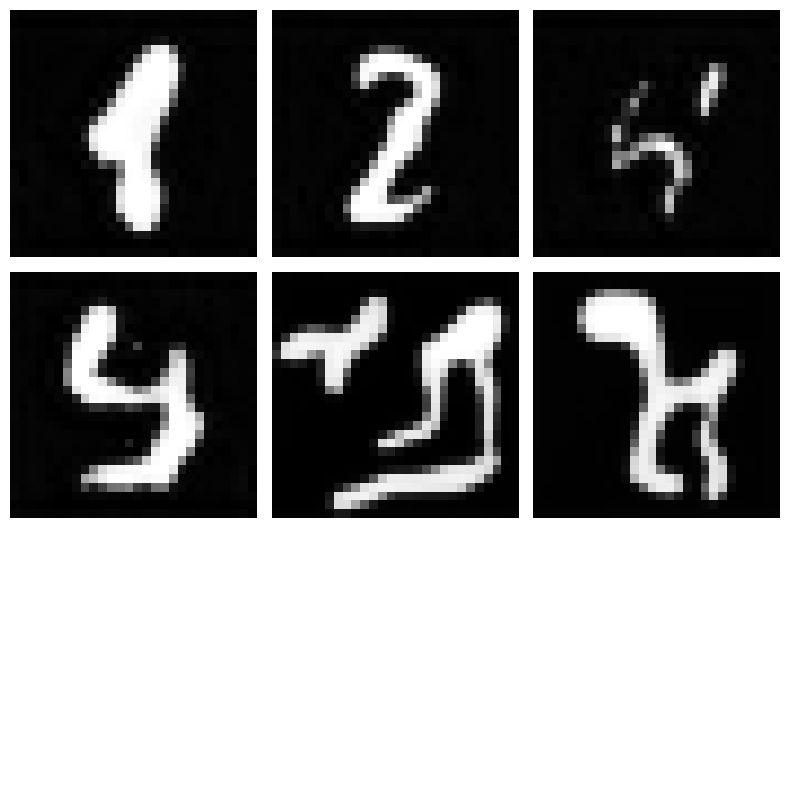

In [22]:
# Fix: Properly load the EMA model
def load_ema_model(checkpoint_path, device='cuda'):
    """Properly load EMA model from checkpoint"""
    # First, create the model architecture (same as training)
    model = MiniUnetFiLM(base_channels=16, condition_dim=64, use_morphometrics=False)
    
    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Create EMA wrapper and load the EMA state dict
    ema = EMA(model, decay=0.999, device=device)
    ema.load_state_dict(checkpoint['ema_state_dict'])
    
    # Return the EMA model
    return ema.module.to(device)

sampling_model = load_ema_model('morpho_ckpt_90.pth', device=device)
sampling_model.eval()
rf=RectifiedFlow()
# Now this will work:
samples = generate_samples_with_ema(
    sampling_model,
    rf=rf,
    y=torch.tensor([7, 7, 7, 7, 3, 3]),  # Mixed digits
    num_samples=6,
    morpho=None,
    num_steps=50,
    cfg_scale=1,
    device=device
)